# Experiment 4 (E4): Sentiment Model Error Analysis

This notebook performs a qualitative and quantitative **error analysis** of the fine-tuned RoBERTa sentiment classifier (3-class: Negative / Neutral / Positive) on the TweetEval `sentiment` test split.

**Goal:** go beyond a single aggregate accuracy number and understand *where* the model fails, *why* it fails there, and *how much* of that failure is a genuine model weakness versus dataset/annotation noise.

**Workflow covered in this notebook:**
1. Load the held-out test set and the trained model checkpoint.
2. Run inference on the full test split and collect predictions.
3. Quantify per-class error rates and identify the dominant confusion pathways.
4. Slice out targeted error subsets (e.g. Neutral→Negative, Positive→Neutral) and manually read samples from each.
5. Summarize the qualitative findings into a structured, evidence-backed narrative of failure modes.

---
### Setup & Imports
Standard library, data/plotting, PyTorch, and HuggingFace imports used throughout the notebook, plus the `sklearn` metrics used for the confusion matrix and classification report.

In [1]:
# Python std
import re
import random

# Data/numeric and Visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pytorch
import torch
from torch.utils.data import Dataset, DataLoader

# Huggingface
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, set_seed

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

### Configuration Constants
Fixed hyperparameters and paths used for reproducible inference:
- `SEED` — random seed for reproducibility across numpy/torch/HF.
- `BATCH_SIZE` — inference batch size for the DataLoader.
- `MAX_LENGTH` — max token length for tokenization/truncation.
- `MODEL_PATH` — path to the fine-tuned checkpoint (previously trained in the baseline/fine-tuning notebooks).

In [2]:
# Constants
SEED = 42
BATCH_SIZE = 128
MAX_LENGTH = 128
MODEL_PATH = r'/kaggle/input/models/dhruvparmar1218/senti-model/pytorch/default/1'

### Device Selection
Selects the best available compute device — CUDA GPU, Apple MPS, or CPU fallback — so inference runs on whatever hardware is available.

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
DEVICE

device(type='cuda')

### Reproducibility
Sets all relevant random seeds (Python `random`, NumPy, PyTorch, and HuggingFace's `set_seed`) so that sampling and any stochastic operations later in the notebook (e.g. `.sample(random_state=SEED)`) are reproducible.

In [4]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

set_all_seeds(SEED)

### Load Datasets
Loads both TweetEval subtasks from HuggingFace (`sentiment` and `hate`), though this notebook focuses on the **sentiment** task. The dataset is converted to pandas format for easier manipulation, and the train/validation/test splits are extracted separately.

In [5]:
ds_senti = load_dataset("cardiffnlp/tweet_eval", "sentiment")
ds_hate = load_dataset("cardiffnlp/tweet_eval", "hate")

ds_senti.set_format(type="pandas")
senti_train = ds_senti["train"][:]
senti_val = ds_senti["validation"][:]
senti_test = ds_senti["test"][:]

README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

...

hate/test-00000-of-00001.parquet:   0%|          | 0.00/278k [00:00<?, ?B/s]

hate/validation-00000-of-00001.parquet:   0%|          | 0.00/103k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2970 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

### Text Cleaning Function
Defines the same preprocessing routine used during training, applied here for consistency at inference time:
1. Lowercasing
2. Anonymizing user mentions (`@someone` → `@user`), while leaving already-anonymized mentions untouched
3. Stripping URLs
4. Removing the `#` character while keeping the hashtag's text content
5. Normalizing whitespace (strip + collapse internal spaces)

In [6]:
def clean_text(text):

    # 1. Lowercase
    lower_text = text.lower()

    # 2. User anonymization
    mention_pattern = r'@(?!user)\w+'
    anony_text = re.sub(mention_pattern, ' @user', lower_text)

    # 3. URL Removal
    no_url_text = re.sub(r'https?://\S+', '', anony_text)
    
    # 4. Stripping hashtag but keeping hastag content
    removed_hash_text = no_url_text.replace("#", "")
    
    # 5. Normalize whitespace(strip + collapse internal spaces)
    stripped_text = removed_hash_text.strip()
    cleaned_text = " ".join(stripped_text.split())

    return cleaned_text

### Apply Cleaning
Applies `clean_text` to the train, validation, and test splits, producing a new `clean_text` column that will be fed into the tokenizer.

In [7]:
senti_train["clean_text"] = senti_train["text"].apply(clean_text)
senti_val["clean_text"] = senti_val["text"].apply(clean_text)
senti_test["clean_text"] = senti_test["text"].apply(clean_text)

### Sanity Check — Split Sizes
Quick shape check to confirm the train/validation/test splits loaded as expected before proceeding.

In [8]:
print(senti_train.shape, senti_val.shape, senti_test.shape)

(45615, 3) (2000, 3) (12284, 3)


### PyTorch Dataset Wrapper
`TweetDataset` wraps the cleaned text + labels and tokenizes on the fly inside `__getitem__`, returning `input_ids`, `attention_mask`, and `labels` tensors ready for batching via `DataLoader`.

In [9]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer 
        self.max_length = max_length
    
    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx) -> dict:
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize the text on the fly
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,      # Adds <s> and </s>
            max_length=self.max_length,   # Cuts off long text
            padding="max_length",         # Pads short text with zeros
            truncation=True,              # Keeps shape consistent
            return_tensors="pt"           # Returns PyTorch Tensors directly
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

### Load Tokenizer
Loads the tokenizer matching the fine-tuned checkpoint at `MODEL_PATH`.

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

### Build Dataset Objects
Instantiates `TweetDataset` for the train, validation, and test splits using the cleaned text and the loaded tokenizer.

In [11]:
senti_train_ds = TweetDataset(senti_train['clean_text'], senti_train['label'], tokenizer, MAX_LENGTH)
senti_val_ds = TweetDataset(senti_val['clean_text'], senti_val['label'], tokenizer, MAX_LENGTH)
senti_test_ds = TweetDataset(senti_test['clean_text'], senti_test['label'], tokenizer, MAX_LENGTH)

### Sanity Check — Dataset Length & Sample Item
Confirms the dataset length and inspects a single tokenized example to verify the `__getitem__` output shape/keys are correct before running inference.

In [12]:
print(senti_train.__len__())
senti_train_ds.__getitem__(0)

45615


{'input_ids': tensor([    0,   113, 39452,   787, 12105,    11,     5,  1461,  2479,     9,
             5,   262,   212,  1040,     6,  6398,   687,   784,   658,   179,
          5601,     5,  2168,     9, 25663, 36560,     4,  1372, 33272,  1208,
          5593,   687,   462,   658,   179,   113,     2,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,   

### Sanity Check — Raw Cleaned Text
Inspects the cleaned text of the first training example directly, as a human-readable cross-check against the tokenized output above.

In [13]:
senti_train['clean_text'][0]

'"qt @user in the original draft of the 7th book, remus lupin survived the battle of hogwarts. happybirthdayremuslupin"'

### Load Fine-Tuned Model
Loads the fine-tuned sequence classification model (3 labels: Negative / Neutral / Positive) from the checkpoint and moves it to the selected device.

In [14]:
# Load the model configuration and architecture
senti_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, num_labels = 3)

# Move all model weights and parameters to the chosen device memory
senti_model = senti_model.to(DEVICE)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

### Test DataLoader
Builds a `DataLoader` over the test set with `shuffle=False` so prediction order stays aligned with the original test dataframe. The model is also switched to `eval()` mode to disable dropout for deterministic inference.

In [15]:
# Initialize DataLoader (Preserves order, keeps all 12,284 examples)
test_dataloader = DataLoader(
    senti_test_ds, 
    batch_size = BATCH_SIZE, 
    shuffle = False, 
    drop_last = False
)

senti_model.to(DEVICE)
senti_model.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

### Run Inference on Test Set
Iterates over the full test set in batches with gradients disabled (`torch.no_grad()`), computes predicted class via `argmax` on the logits, and collects predictions/labels into a single `inference_results` DataFrame alongside the original and cleaned text. This DataFrame is the foundation for every error-analysis step that follows.

**Note:** this is the most expensive cell in the notebook — it performs a full forward pass over all test examples.

In [16]:
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)
        
        outputs = senti_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        preds = torch.argmax(logits, dim=1)
        
        # Explicitly detach, move to CPU, and convert to numpy
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

# Combine batches
final_preds = np.concatenate(all_preds, axis=0)
final_labels = np.concatenate(all_labels, axis=0)

# Build results DataFrame
inference_results = pd.DataFrame({
    "text": senti_test["text"].values,
    "clean_text": senti_test["clean_text"].values,
    "true_label": final_labels,
    "predicted_label": final_preds
})

# Final length verification
print(f"Total rows processed: {len(inference_results)}")

Total rows processed: 12284


## Step 1 — Isolate Misclassified Examples
Filters `inference_results` down to only the rows where the predicted label disagrees with the true label, keeping just the columns needed for qualitative review. This `misclassified_df` is reused throughout the rest of the error analysis.

In [17]:
# 1. Filter for misclassified rows where predicted does not match true
misclassified_df = inference_results[
    inference_results["predicted_label"] != inference_results["true_label"]
]

# 2. Select only the specified columns
misclassified_df = misclassified_df[
    ["clean_text", "text", "predicted_label", "true_label"]
].reset_index(drop=True)

# 3. Verification
print(f"Total misclassified rows: {len(misclassified_df)}")

Total misclassified rows: 3473


## Step 2 — Per-Class Error Rates
Computes, for each of the three sentiment classes, how many of its true examples were misclassified (error rate) — a quick way to see which class the model struggles with most before diving into confusion-matrix detail.

In [18]:
# Map class integers to text names
class_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
print("--- Class Error Rates ---")
for class_idx, class_name in class_map.items():
    # 1. Count total true samples for this class
    total_true = (inference_results["true_label"] == class_idx).sum()
    # 2. Count mistakes made on this class
    total_wrong = (
        (inference_results["true_label"] == class_idx)
        & (inference_results["predicted_label"] != class_idx)
    ).sum()
    # 3. Calculate percentage
    error_rate = (total_wrong / total_true) * 100 if total_true > 0 else 0
    print(
        f"{class_name:<8} Class | Total Samples: {total_true:<5} | Errors: {total_wrong:<5} | Error Rate: {error_rate:.2f}%"
    )

--- Class Error Rates ---
Negative Class | Total Samples: 3972  | Errors: 730   | Error Rate: 18.38%
Neutral  Class | Total Samples: 5937  | Errors: 2019  | Error Rate: 34.01%
Positive Class | Total Samples: 2375  | Errors: 724   | Error Rate: 30.48%


## Step 3 — Define Error Subsets for Qualitative Inspection
Rather than reading through thousands of misclassified rows unguided, the errors are split into five targeted subsets based on the (true → predicted) label pair, matching known/likely failure modes (e.g. lukewarm language, sarcasm, mixed polarity). This sets up a structured, evidence-based sample for the manual review that follows.

In [19]:
# Mapping: 0 = Negative, 1 = Neutral, 2 = Positive

# 1. Define the boolean masks using numeric labels
mask_lukewarm = (misclassified_df['true_label'] == 1) & (misclassified_df['predicted_label'] == 2)
mask_sarcasm_fp = (misclassified_df['true_label'] == 0) & (misclassified_df['predicted_label'] == 2)
mask_sarcasm_fn = (misclassified_df['true_label'] == 0) & (misclassified_df['predicted_label'] == 1)
mask_mixed_polarity = (misclassified_df['true_label'] == 2) & (misclassified_df['predicted_label'] == 1)
mask_bleak_neutral_topics = (misclassified_df['true_label'] == 1) & (misclassified_df['predicted_label'] == 0)

# 2. Extract the absolute counts
count_lukewarm = mask_lukewarm.sum()
count_sarcasm_fp = mask_sarcasm_fp.sum()
count_sarcasm_fn = mask_sarcasm_fn.sum()
count_mixed_polarity = mask_mixed_polarity.sum()
count_bleak_neutral_topics = mask_bleak_neutral_topics.sum()
total_errors = len(misclassified_df)

# 3. Print the sizing report
print("==================================================")
print("SUBSET SIZING FOR QUALITATIVE INSPECTION")
print("==================================================")
print(f"Subset A: Lukewarm Language             (1 -> 2)  | Count: {count_lukewarm:<5} | ({count_lukewarm/total_errors:.1%} of total errors)")
print(f"Subset B: Sarcasm/Negation              (0 -> 2)  | Count: {count_sarcasm_fp:<5} | ({count_sarcasm_fp/total_errors:.1%} of total errors)")
print(f"Subset C: Negative Softened to Neutral  (0 -> 1)  | Count: {count_sarcasm_fn:<5} | ({count_sarcasm_fn/total_errors:.1%} of total errors)")
print(f"Subset D: Mixed Polarity                (2 -> 1)  | Count: {count_mixed_polarity:<5} | ({count_mixed_polarity/total_errors:.1%} of total errors)")
print(f"Subset E: Bleak neutral topics          (1 -> 0)  | Count: {count_bleak_neutral_topics:<5} | ({count_bleak_neutral_topics/total_errors:.1%} of total errors)")
print("==================================================")
print(f"Total Misclassified Examples Analysed: {total_errors}")

SUBSET SIZING FOR QUALITATIVE INSPECTION
Subset A: Lukewarm Language             (1 -> 2)  | Count: 559   | (16.1% of total errors)
Subset B: Sarcasm/Negation              (0 -> 2)  | Count: 53    | (1.5% of total errors)
Subset C: Negative Softened to Neutral  (0 -> 1)  | Count: 677   | (19.5% of total errors)
Subset D: Mixed Polarity                (2 -> 1)  | Count: 630   | (18.1% of total errors)
Subset E: Bleak neutral topics          (1 -> 0)  | Count: 1460  | (42.0% of total errors)
Total Misclassified Examples Analysed: 3473


## Step 4 — Sample and Print Error Subsets
Draws a fixed, seeded random sample from each error subset (sizes chosen to reflect their share of total errors — larger subsets get more samples) and prints them in a human-readable format for manual linguistic inspection.

The qualitative findings from reading through these printed samples are documented in the markdown analysis immediately below (Subsets A–E).

In [20]:
# Define the display columns requested
display_cols = ['text', 'true_label', 'predicted_label']

# --- 1. Extract the Samples ---
# Subset E: Neutral -> Negative (35 samples)
pool_e = misclassified_df[(misclassified_df['true_label'] == 1) & (misclassified_df['predicted_label'] == 0)]
sample_e = pool_e.sample(n=min(35, len(pool_e)), random_state=SEED)[display_cols]

# Subset A: Neutral -> Positive (20 samples)
pool_a = misclassified_df[(misclassified_df['true_label'] == 1) & (misclassified_df['predicted_label'] == 2)]
sample_a = pool_a.sample(n=min(20, len(pool_a)), random_state=SEED)[display_cols]

# Subset C: Negative -> Neutral (20 samples)
pool_c = misclassified_df[(misclassified_df['true_label'] == 0) & (misclassified_df['predicted_label'] == 1)]
sample_c = pool_c.sample(n=min(20, len(pool_c)), random_state=SEED)[display_cols]

# Subset D: Positive -> Neutral (15 samples)
pool_d = misclassified_df[(misclassified_df['true_label'] == 2) & (misclassified_df['predicted_label'] == 1)]
sample_d = pool_d.sample(n=min(15, len(pool_d)), random_state=SEED)[display_cols]

# Subset B: Negative -> Positive (7 samples)
pool_b = misclassified_df[(misclassified_df['true_label'] == 0) & (misclassified_df['predicted_label'] == 2)]
sample_b = pool_b.sample(n=min(7, len(pool_b)), random_state=SEED)[display_cols]


# --- 2. Printing Function ---
def print_readable_subset(title, sample_df):
    print("=" * 80)
    print(f" {title} (Total Examples: {len(sample_df)})")
    print("=" * 80)
    
    for idx, row in enumerate(sample_df.itertuples(), 1):
        print(f"[{idx}] True: {row.true_label} | Pred: {row.predicted_label}")
        print(f"Text: {row.text}")
        print("-" * 80)
    print("\n" * 2)

# --- 3. Execute Printing ---
print_readable_subset("SUBSET E: NEUTRAL -> NEGATIVE (Core Leakage)", sample_e)
print_readable_subset("SUBSET A: NEUTRAL -> POSITIVE (Core Leakage)", sample_a)
print_readable_subset("SUBSET C: NEGATIVE -> NEUTRAL (Garbage Bin Intake)", sample_c)
print_readable_subset("SUBSET D: POSITIVE -> NEUTRAL (Garbage Bin Intake)", sample_d)
print_readable_subset("SUBSET B: NEGATIVE -> POSITIVE (Extreme Flips)", sample_b)

 SUBSET E: NEUTRAL -> NEGATIVE (Core Leakage) (Total Examples: 35)
[1] True: 1 | Pred: 0
Text: Debate on the repeal of Obamacare will make it obvious to American people that this system was created in their fav…
--------------------------------------------------------------------------------
[2] True: 1 | Pred: 0
Text: @user Next up in the narrative : Saakashvili is a kremlin agent.
--------------------------------------------------------------------------------
[3] True: 1 | Pred: 0
Text: Grateful for these bad hombres
--------------------------------------------------------------------------------
[4] True: 1 | Pred: 0
Text: Northern Ireland abortion campaign opponents reveal crisis pregnancies at 20
--------------------------------------------------------------------------------
[5] True: 1 | Pred: 0
Text: For Dems to recover, Nancy Pelosi, her team should go@Milbank + rep Ryan are CLUELESS about Dem probs
-----------------------------------------------------------------------------

## Subset E: Neutral → Negative (Core Leakage Boundary)
Linguistic inspection of the 35 sampled errors reveals that the widespread leakage from the Neutral to the Negative class is fundamentally driven by two distinct mechanisms rather than ambiguous phrasing or multi-party confusion. The first and most prominent mechanism, accounting for 16 of the 35 inspected examples, is the model's severe over-sensitisation to partisan entities, political vocabulary, and hostile discourse framing. The classifier assigns extreme negative bias vectors to polarizing proper nouns ("Steve Bannon," "Nancy Pelosi," "Romney") and systemic policy flashpoints ("Obamacare," "identity politics," "the TPP"). It is completely blind to instances where these tokens appear in purely analytical, neutral, or non-hostile configurations, and it routinely misinterprets standard political counter-arguments or state-of-fact observations as true negative affect. This failure mode is heavily compounded by an inability to parse high-arousal verbs like "yells" or hostile culturally loaded phrases ("bad hombres") when they are explicitly subverted or paired with positive modifiers ("Grateful for these bad hombres"). The second mechanism, observed in 5 examples, involves a context-blind reliance on unigram token weights when processing objective news reporting on bleak societal subject matter. When processing dry, journalistic headlines detailing war, terrorism, or physical danger, the classifier over-indexes on high-affinity negative tokens ("stabbing," "terrorist," "air-strikes," "deadliest") and strips away the descriptive nature of the text, misclassifying structural news updates as Negative.
The remaining 14 cases in this subset reflect a combination of lexical register mismatches, formatting confounders, and deep ground-truth annotation noise. A minor structural failure (observed in 2 examples) occurs when the model encounters non-standard language registers and African American Vernacular English (AAVE); it parses inverted semantic identifiers ("ill" or "sick" used as expressions of excellence) literally, defaulting to an incorrect negative score. Furthermore, intense formatting syntax such as all-caps intensifiers ("THAT SANDY HOOK GUN CONTROL VIDEO REALLY SHOOK ME UP") acts as a procedural confounder that forces an automatic negative classification based on structural arousal signals alone. Crucially, a significant block of 11 residual cases represents baseline data noise and annotation anomalies rather than structural model failures. In instances where users display explicit distress markers (":((", "#euthanasia") regarding lab procedures, or deploy inherently negative-valenced linguistic dismissals ("quackery"), the model’s Negative prediction is arguably more defensible than the assigned Neutral ground truth. Similarly, pragmatic discourse markers signaling mild personal exasperation ("🙄"), heavily truncated or broken strings ("FACT: Robots cannot, and then shipped worldwide for global communism"), and sparse narrative progressions inject noticeable baseline label noise, demonstrating that rigid or erroneous ground-truth tagging heavily penalizes valid model classifications at this boundary.
## Subset A: Neutral $\rightarrow$ Positive (Core Leakage Boundary)
Linguistic inspection of the 20 sampled errors reveals that the widespread leakage from the Neutral to the Positive class is fundamentally driven by two distinct mechanisms rather than ambiguous, lukewarm phrasing. The first and most prominent mechanism, accounting for roughly 12 of the 20 inspected examples, is the model's failure to handle domain shifts regarding factual medical, corporate, and socio-political text. For instance, in clinical or promotional advertisements (e.g., abortion pill listings), the classifier over-indexes on high-affinity, contextually sterile tokens like "safe," "solution," or "healthcare" and strips away the descriptive nature of the text, misclassifying objective information as Positive. The second mechanism, observed in the remaining 8 examples, involves the literal interpretation of weaponized cultural tokens and syntactic reversals. The model treats uppercase text ("HILL YES!!"), political slogans ("#ImWithHer"), and text stringing together multiple laughing emojis as literal indicators of exuberant consumer joy. It is completely blind to modern social media structures where humor and agreement markers are heavily subverted to signal aggressive political identity, mockery, or deep partisan disagreement ("Couldn't disagree more!").
## Subset C: Negative $\rightarrow$ Neutral (The "Garbage Bin" Intake Boundary)
The high 34% error rate in the Neutral class is heavily compounded by its behavior as an intake "garbage bin" for true negative sentiments, a failure driven primarily by complex journalistic structures and multi-entity political conflict. Out of the 20 sampled text samples, approximately 13 show a structural vulnerability to factual, news-style reporting of bleak societal issues. When processing grim or criminal subject matter (e.g., reports on drug trafficking, rising sea levels, or white nationalist conferences), the model mistakes a formal, objective, or narrative tone for conceptual neutrality simply because the text lacks overt, explosive negative emotional adjectives. The remaining 7 cases illustrate a complete breakdown in multi-entity sentiment tracking and localized nuance. When a text sets up a multi-party political accusation or a call-to-action to block a candidate, the sentence naturally balances conflicting partisan proper nouns (e.g., "GOP Senators," "Trump," "Democratic Party"). Lacking the ability to parse who is attacking whom, the model treats the text as a baseline political statement of fact and defaults to Neutral. Furthermore, brief, highly ambiguous ground-truth strings such as "Pop is gay for Tim Duncan" introduce noticeable baseline label noise; without explicit structural context, it is impossible to verify whether the phrase represents a pejorative attack or intense adoration, making its assignment to the Neutral class a reflection of structural ambiguity rather than a clear model failure.
## Subset D: Positive $\rightarrow$ Neutral (The "Garbage Bin" Intake Boundary)
The opposite side of the "garbage bin" narrative accounts for an 18.1% slice of the error pool, where true positive text is flattened into Neutral due to structural ad formats and unmapped emotional vocabulary. Among the 15 sampled instances, roughly 9 exhibit an over-reliance on functional promotional vocabulary. Standard marketing listing practices that leverage tokens like "SALE," "Deals," or "talking plush" were systematically categorized as Positive by human annotators under the assumption of commercial endorsement. However, because these listings lack any subjective or explicit emotional sentiment, this subset partially reflects annotation noise rather than model failure. The remaining 6 examples show a clear vulnerability to informational hype and slang context. The model regularly drops instances of anticipation, excitement, or camaraderie into the Neutral bucket when expressed through non-standard internet slang ("bad hombres," "hell yeah") or capitalised expressions of interest ("I WANT TO GO SEE"). Because the classifier's vocabulary baseline lacks deep, contemporary socio-cultural mappings, it cannot transform raw excitement into a positive sentiment score, causing it to wash these out as neutral data points.
## Subset B: Negative $\rightarrow$ Positive (Extreme Boundary Flips)
Accounting for a minimal 1.5% of total errors, this subset represents a minor systemic leak but showcases the model's absolute blind spot regarding complex rhetorical architecture. In 6 out of the 7 sampled examples, the model acts as a surface-level keyword matcher that is completely neutralized by backhanded compliments, hypothetical conditionals, and emotional pivots. For instance, in sentences structured around conditional critiques ("If all alt-rightists looked this good Trump would have won..."), the model strips out the conditional operator "If" and aggregates the positive weights of "good" and "won" to output a false positive. Similarly, it is easily deceived by rhetorical ironies where highly positive words ("agree," "passion," "articulate") are explicitly weaponized to set up a negative punchline about plagiarism. Conversely, the final example in this subset ("#WESTWORLD Dolores is MF Wyatt... I love shows like this") exposes a blatant ground-truth annotation artifact rather than a model failure. The text explicitly culminates in a highly positive sentiment statement ("I love shows like this"), yet was incorrectly labeled as Negative by human annotators—likely due to a rigid schema restriction against aggressive profanity. In this instance, the model’s prediction of Positive is objectively correct, demonstrating that boundary noise exists on both sides of the dataset.

## Step 5 — Confusion Matrix Visualization
Builds the 3×3 confusion matrix in two forms, shown side by side:
- **Raw counts** — absolute number of errors per (true, predicted) pair, useful for prioritizing which failure mode to investigate first.
- **Row-normalized (recall)** — each row sums to 1, showing what fraction of a given true class was predicted as each class, independent of class size.

This quantitative view is what motivates the subset definitions and sampling sizes used in Steps 3–4 above.

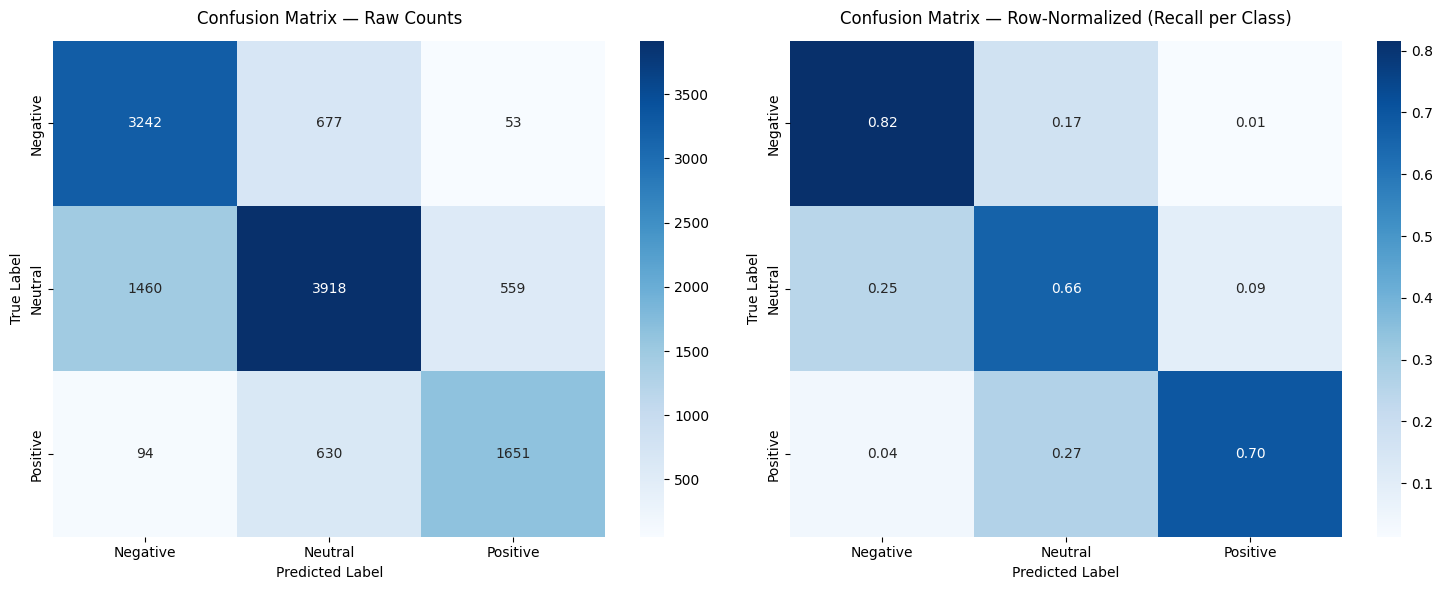

In [21]:
# Define structural ordering to ensure zero-mismatch mapping
labels_order = [0, 1, 2]
class_names = ['Negative', 'Neutral', 'Positive']

# 1. Strict DataType validation: Enforce standard Python integers to bypass pandas/numpy wrapper mismatches
y_true = inference_results['true_label'].astype(int)
y_pred = inference_results['predicted_label'].astype(int)

# 2. Compute raw values and row-normalized scores
cm_raw = confusion_matrix(y_true, y_pred, labels=labels_order)
cm_norm = confusion_matrix(y_true, y_pred, labels=labels_order, normalize='true')

# 3. Generate the side-by-side subplot visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left Subplot: Raw sample scale counts (Independent scale optimized for sample size distribution)
sns.heatmap(
    cm_raw, 
    annot=True, 
    fmt='d', 
    ax=axes[0], 
    xticklabels=class_names, 
    yticklabels=class_names, 
    cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=12, pad=12)
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

# Right Subplot: Row-normalized error distributions (Independent scale optimized for class recall rates)
sns.heatmap(
    cm_norm, 
    annot=True, 
    fmt='.2f', 
    ax=axes[1], 
    xticklabels=class_names, 
    yticklabels=class_names, 
    cmap='Blues'
)
axes[1].set_title('Confusion Matrix — Row-Normalized (Recall per Class)', fontsize=12, pad=12)
axes[1].set_xlabel('Predicted Label', fontsize=10)
axes[1].set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()

## Interpretation
The confusion matrix is presented in two complementary forms because each answers a different analytical question. The **raw-count matrix** quantifies the absolute volume of misclassifications and is therefore used to prioritize investigation effort, revealing which failure modes contribute most to overall error. In contrast, the **row-normalized matrix** removes class-size effects and shows the direction of each class's errors (i.e., recall structure), making it possible to compare error pathways independently of the underlying label distribution. Together, the two panels distinguish **how many** errors occur from **where** those errors are directed.
The raw-count matrix identifies **Neutral → Negative (1,460)** as by far the largest off-diagonal cell, accounting for approximately **42% of all 3,473 misclassifications**, directly motivating the creation and prioritization of **Subset E**. The next largest cells are **Negative → Neutral (677)** and **Positive → Neutral (630)**, corresponding to **Subsets C** and **D**, respectively, while **Neutral → Positive (559)** forms **Subset A**. In contrast, **Negative → Positive (53)** is negligible and therefore analysed as **Subset B** only after the higher-impact failure modes. This ordering reflects analytical importance rather than simply following matrix position: the confusion matrix serves as the quantitative justification for the progression of the subsequent qualitative analyses.
The normalized matrix provides an additional finding that is not apparent from raw counts alone. The **negative class achieves the highest recall (0.82)** and also has the **lowest absolute error count (730)**, indicating that it is the model's most reliably recognized sentiment class. More importantly, the residual errors of both boundary classes exhibit a strong directional asymmetry. Of the **730 negative misclassifications**, **677 (≈93%)** are predicted as **neutral** (Subset C), while only **53 (≈7%)** are predicted as **positive** (Subset B). Likewise, of the **724 positive misclassifications**, **630 (≈87%)** are predicted as **neutral** (Subset D), compared with only **94 (≈13%)** predicted as **negative**. Although the Positive → Negative cell is larger than Negative → Positive in absolute terms, it represents a relatively small share of overall error and the neutral-boundary failure mode (garbage bin) already explains 95.8% (~96%) of misclassifications [1460+677+630+559 = 3326/3473], and non-neutral polarity flips (Negative→Positive (Subset B, 53) and Positive→Negative (94)) are a separate, smaller phenomenon we're scoping out of E4 (Experiment 4 - Error Analysis) for time. Taken together, these parallel asymmetries show that when the model is uncertain, predictions overwhelmingly collapse into the neutral class rather than directly crossing between opposite sentiment polarities, quantitatively reinforcing the "neutral as a garbage-bin class" interpretation examined qualitatively in Section 6.

## Step 6 — Per-Class Summary Table
Consolidates support, error count, error rate, and recall per class into a single summary table, plus two aggregate rows (overall accuracy and macro-averaged recall). Assertions verify internal consistency (e.g. error counts sum correctly, error rate + recall = 1 per row) before display.

In [29]:
label_map = senti_model.config.id2label  # dynamic, not hardcoded — matches Section 7 practice

summary_rows = []
for label in sorted(inference_results["true_label"].unique()):
    support = (inference_results["true_label"] == label).sum()
    errors = (
        (inference_results["true_label"] == label)
        & (inference_results["true_label"] != inference_results["predicted_label"])
    ).sum()
    error_rate = errors / support
    recall = 1 - error_rate
    summary_rows.append({
        "Class": label_map[label].capitalize(),
        "Support": support,
        "Errors": errors,
        "Error Rate": round(error_rate, 4),
        "Recall": round(recall, 4)
    })

overall_support = len(inference_results)
overall_errors = len(misclassified_df)
overall_accuracy = 1 - overall_errors / overall_support
macro_recall = sum(r["Recall"] for r in summary_rows) / len(summary_rows)

# Two distinct overall rows — not conflated into one
summary_rows.append({
    "Class": "Overall (accuracy)",
    "Support": overall_support,
    "Errors": overall_errors,
    "Error Rate": round(1 - overall_accuracy, 4),
    "Recall": round(overall_accuracy, 4)  # accuracy, self-consistent within this row
})
summary_rows.append({
    "Class": "Overall (macro recall)",
    "Support": overall_support,
    "Errors": overall_errors,
    "Error Rate": round(1 - macro_recall, 4),
    "Recall": round(macro_recall, 4)  # 1 - Error Rate holds within this row too
})

error_summary_df = pd.DataFrame(summary_rows)

assert overall_errors == sum(r["Errors"] for r in summary_rows[:3])
assert overall_support == sum(r["Support"] for r in summary_rows[:3])
for row in summary_rows:
    assert abs((1 - row["Error Rate"]) - row["Recall"]) < 1e-6, f"Inconsistent row: {row['Class']}"

display(error_summary_df)

,Class,Support,Errors,Error Rate,Recall
0,Negative,3972,730,0.1838,0.8162
1,Neutral,5937,2019,0.3401,0.6599
2,Positive,2375,724,0.3048,0.6952
3,Overall (accuracy),12284,3473,0.2827,0.7173
4,Overall (macro recall),12284,3473,0.2762,0.7238


## Step 7 — Off-Diagonal Error Crosstab Mapped to Subsets
Builds a crosstab of all (true → predicted) error pairs, cross-references each against the qualitative subsets defined earlier (A–E), and reports each pair's share of total errors. The `Positive → Negative` cell is intentionally left unsampled/uncharacterized (flagged as scoped out) since it was not part of the qualitative review in Step 4. An assertion confirms the crosstab total matches the overall misclassified count.

In [33]:
error_crosstab = pd.crosstab(
    misclassified_df["true_label"].map(label_map).str.capitalize(),
    misclassified_df["predicted_label"].map(label_map).str.capitalize()
)

subset_map = {
    ("Neutral", "Negative"): ("E", 35),
    ("Negative", "Neutral"): ("C", 20),
    ("Positive", "Neutral"): ("D", 15),
    ("Neutral", "Positive"): ("A", 20),
    ("Negative", "Positive"): ("B", 7),
    ("Positive", "Negative"): (None, 0),
}

rows = []
for (true_lbl, pred_lbl), (subset, n_sampled) in subset_map.items():
    count = error_crosstab.loc[true_lbl, pred_lbl]
    rows.append({
        "True → Predicted": f"{true_lbl} → {pred_lbl}",
        "Count": int(count),
        "% of Total Errors": round(100 * count / len(misclassified_df), 2),
        "Subset": subset if subset else "Unsampled (scoped out — Sec 7)",
        "Sampled n": n_sampled
    })

offdiag_df = pd.DataFrame(rows).sort_values("Count", ascending=False).reset_index(drop=True)

assert offdiag_df["Count"].sum() == len(misclassified_df), \
    f"Mismatch: {offdiag_df['Count'].sum()} vs {len(misclassified_df)}"

display(offdiag_df)

,True → Predicted,Count,% of Total Errors,Subset,Sampled n
0,Neutral → Negative,1460,42.04,E,35
1,Negative → Neutral,677,19.49,C,20
2,Positive → Neutral,630,18.14,D,15
3,Neutral → Positive,559,16.10,A,20
4,Positive → Negative,94,2.71,Unsampled (scoped out — Sec 7),0
5,Negative → Positive,53,1.53,B,7


| Subset | Cell | n | Dominant mechanism(s) |
|---|---|---|---|
| E | Neutral→Negative | 35 | Over-sensitization to partisan entities/political vocabulary (16/35); context-blind unigram weighting on journalistic negative-affinity tokens (5/35); remainder AAVE/slang register mismatch, formatting confounders, annotation noise (14/35) |
| A | Neutral→Positive | 20 | Domain-shift blindness on factual medical/corporate/socio-political text (approx. 12/20); literal interpretation of weaponized cultural tokens missing irony/mockery (approx. 8/20) |
| C | Negative→Neutral | 20 | Structural vulnerability to formal/journalistic reporting of bleak topics (approx. 13/20); breakdown in multi-entity political sentiment tracking (approx. 7/20) |
| D | Positive→Neutral | 15 | Promotional/commercial listings under annotation convention (approx. 9/15, arguably annotation noise); vocabulary gap on informational hype/slang/anticipation (approx. 6/15) |
| B | Negative→Positive | 7 | Surface-level keyword-matching on backhanded compliments, stripped conditionals, rhetorical irony (6/7); 1 confirmed ground-truth annotation error (1/7) |
| — | Positive→Negative | 0 | Unsampled — scoped out (Sec 7); mechanism unverified, not to be characterized |

## Summary

E4 error analysis confirms that E3's root cause — lexical ambiguity from charged political vocabulary, not sample scarcity — extends beyond the neutral class in isolation to a broader, bidirectional pattern: neutral functions as a garbage-bin class in both directions, absorbing misrouted negative and positive predictions (Subsets C, D — 37.6% of errors) while also leaking outward when politically charged or journalistically bleak neutral text is over-read as negative (Subset E alone — 42.0% of errors, the single largest failure mode). Genuine cross-polarity confusion (Negative↔Positive, Subsets B and the unsampled Positive→Negative cell) accounts for only 4.2% of total misclassifications, reinforcing that the model's primary weakness is boundary uncertainty around neutral, not failure to distinguish opposite sentiments. A meaningful fraction of errors across Subsets D, C, and parts of A and E are better characterized as annotation-convention noise or defensible alternative readings than as model failures — a distinction the report should state explicitly rather than treating all 3,473 misclassifications as uniform evidence of model weakness.